# Sales Forecasting — Linear Regression Project
Dataset: [Superstore Sales Dataset (Kaggle)](https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting)

This notebook works through the task sheet phase by phase: Data Collection → Data Preprocessing → Linear Regression (Sales Forecasting).


## Setup — Imports library
Run this once before starting any task.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm

from scipy.stats import skew
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline


## STEP 1: DATA COLLECTION

### Task 1 — Download the Sales dataset from kaggle
Download `train.csv` from the Kaggle dataset link below and place it in our working directory.

Link: https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting

```


In [589]:
# Load the dataset
df = pd.read_csv("train.csv")
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### Task 2 — Load the dataset and record shape, column names, and data types

In [590]:
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (9800, 18)


In [591]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [592]:
print("Data types:")
print(df.dtypes)

Data types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object


In [593]:
print("\nQuick info:")
df.info()



Quick info:
<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: flo

## STEP 2: DATA PREPROCESSING

### Task 1 — Check for and handle missing values

In [594]:
# Check missing values
print("Missing Values per column:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Missing Values per column:
Postal Code      11
Row ID            0
Order ID          0
Order Date        0
Ship Mode         0
Ship Date         0
Customer Name     0
Segment           0
Country           0
Customer ID       0
dtype: int64


In [595]:
# Sales dataset mainly has missing values in 'Postal Code'
df['Postal Code'] = df['Postal Code'].fillna(df['Postal Code'].mode()[0])

print("Remaining missing values :", df.isnull().sum().sum())

Remaining missing values : 0


### Task 2 — Check for and handle duplicate rows

In [596]:
# Check duplicate values
print("Duplicate rows found :", (df.duplicated().sum()))

df = df.drop_duplicates().reset_index(drop=True)
print("\nShape after dropping duplicates:", df.shape)


Duplicate rows found : 0

Shape after dropping duplicates: (9800, 18)


### Task 3 — Identify and drop pure identifier columns

In [597]:
id_cols = [c for c in ['Row ID', 'Order ID', 'Customer ID', 'Product ID'] if c in df.columns]
print("Identifier columns found :", id_cols)

df = df.drop(columns=id_cols)
print("Shape after dropping identifiers :", df.shape)


Identifier columns found : ['Row ID', 'Order ID', 'Customer ID', 'Product ID']
Shape after dropping identifiers : (9800, 14)


### Task 4 — Identify and drop zero-variance / constant columns

In [598]:
constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print("Constant / zero-variance columns:", constant_cols)

df = df.drop(columns=constant_cols)
print("Shape after dropping constant columns:", df.shape)


Constant / zero-variance columns: ['Country']
Shape after dropping constant columns: (9800, 13)


### Task 5 — Convert Order Date and Ship Date to datetime

In [599]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%d/%m/%Y', errors='coerce')

# Fallback parse for any rows that failed with the strict format
if df['Order Date'].isnull().any():
    df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
if df['Ship Date'].isnull().any():
    df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

print(df[['Order Date', 'Ship Date']].dtypes)
df[['Order Date', 'Ship Date']].head()


Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


### Task 6 — Engineer numeric features from Order Date

In [600]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order DayOfWeek'] = df['Order Date'].dt.dayofweek  # Monday=0
first_order_date = df['Order Date'].min()
df['Days Since First Order'] = (df['Order Date'] - first_order_date).dt.days

# Shipping delay can also be a useful engineered numeric feature
df['Shipping Delay Days'] = (df['Ship Date'] - df['Order Date']).dt.days

df[['Order Year', 'Order Month', 'Order DayOfWeek',
    'Days Since First Order', 'Shipping Delay Days']].head()


,Order Year,Order Month,Order DayOfWeek,Days Since First Order,Shipping Delay Days
0,2017,11,2,1040,3
1,2017,11,2,1040,3
2,2017,6,0,891,4
3,2016,10,1,647,7
4,2016,10,1,647,7


### Task 7 — Plot the distribution of Sales and check skewness

Skewness of Sales: 12.981


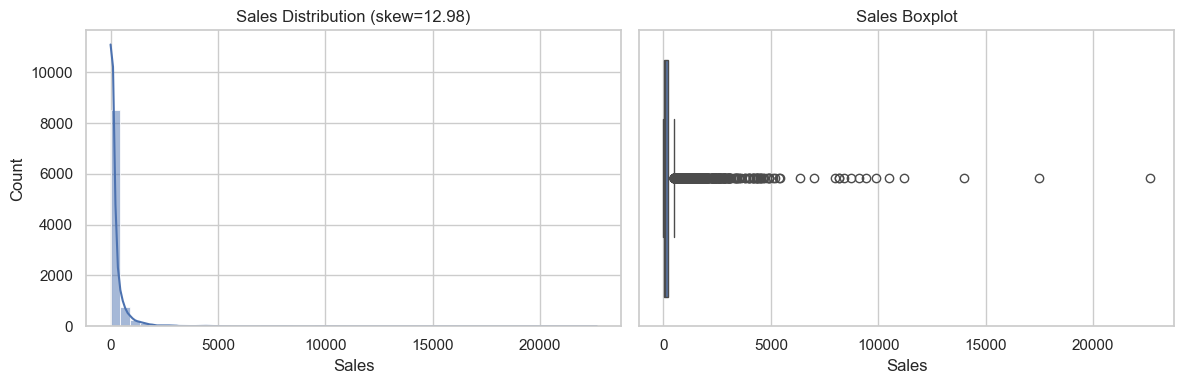

In [601]:
from scipy.stats import skew

sales_skew = skew(df['Sales'])
print(f"Skewness of Sales: {sales_skew:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Sales'], bins=50, kde=True, ax=axes[0])
axes[0].set_title(f"Sales Distribution (skew={sales_skew:.2f})")

sns.boxplot(x=df['Sales'], ax=axes[1])
axes[1].set_title("Sales Boxplot")
plt.tight_layout()
plt.show()


### Task 8 — Apply log1p transform to Sales (keep original too)

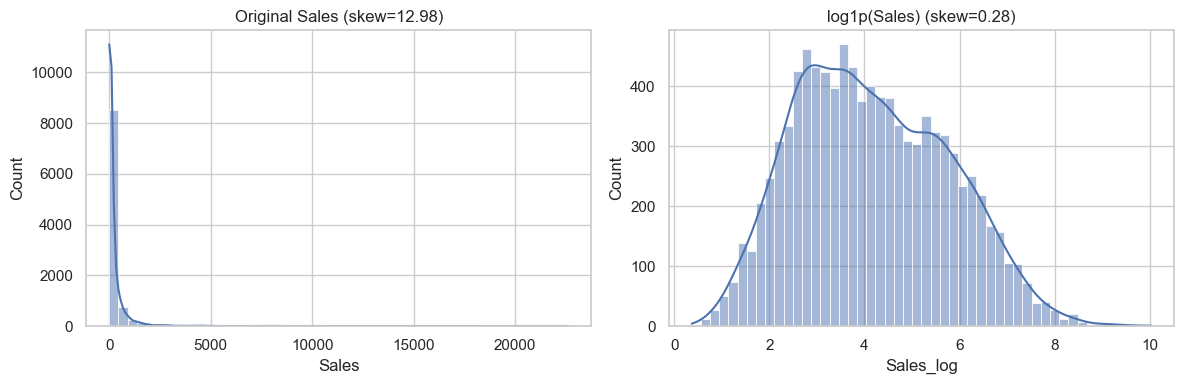

In [602]:
df['Sales_log'] = np.log1p(df['Sales'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Sales'], bins=50, kde=True, ax=axes[0])
axes[0].set_title(f"Original Sales (skew={skew(df['Sales']):.2f})")
sns.histplot(df['Sales_log'], bins=50, kde=True, ax=axes[1])
axes[1].set_title(f"log1p(Sales) (skew={skew(df['Sales_log']):.2f})")
plt.tight_layout()
plt.show()


### Task 9 — List categorical columns and their cardinality

In [603]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cardinality = {c: df[c].nunique() for c in cat_cols}
cardinality_df = pd.DataFrame.from_dict(cardinality, orient='index', columns=['n_unique']).sort_values('n_unique')
display(cardinality_df)


,n_unique
Segment,3
Category,3
Region,4
Ship Mode,4
Sub-Category,17
State,49
City,529
Customer Name,793
Product Name,1849


### Task 10 — Train/test split (70/30) before target-dependent encoding

In [604]:
target_col = 'Sales_log'   # modeling target (log scale)
drop_for_X = ['Sales', 'Sales_log', 'Order Date', 'Ship Date']

X = df.drop(columns=drop_for_X)
y_log = df['Sales_log']
y_original = df['Sales']

X_train, X_test, y_train_log, y_test_log, y_train_orig, y_test_orig = train_test_split(
    X, y_log, y_original, test_size=0.30, random_state=42
)

# Display dataset sizes after splitting
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (6860, 15)
Test shape: (2940, 15)


### Task 11 — One-hot encode low-cardinality categorical columns

In [605]:
low_card_cols = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']
low_card_cols = [c for c in low_card_cols if c in X_train.columns]

ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[low_card_cols])

train_ohe = pd.DataFrame(
    ohe.transform(X_train[low_card_cols]),
    columns=ohe.get_feature_names_out(low_card_cols),
    index=X_train.index
)
test_ohe = pd.DataFrame(
    ohe.transform(X_test[low_card_cols]),
    columns=ohe.get_feature_names_out(low_card_cols),
    index=X_test.index
)

X_train = pd.concat([X_train.drop(columns=low_card_cols), train_ohe], axis=1)
X_test = pd.concat([X_test.drop(columns=low_card_cols), test_ohe], axis=1)

print(f"Train shape: ", X_train.shape)
print(f"Test shape: ", X_test.shape)


Train shape:  (6860, 36)
Test shape:  (2940, 36)


### Task 12 — Target/frequency encode high-cardinality categorical columns

In [606]:
high_card_cols = ['Customer Name', 'Product Name', 'City', 'State']
high_card_cols = [c for c in high_card_cols if c in X_train.columns]

global_mean = y_train_log.mean()

for col in high_card_cols:
    target_map = y_train_log.groupby(X_train[col]).mean()
    X_train[col + '_target_enc'] = X_train[col].map(target_map)
    X_test[col + '_target_enc']  = X_test[col].map(target_map).fillna(global_mean)

X_train = X_train.drop(columns=high_card_cols)
X_test = X_test.drop(columns=high_card_cols)

# Drop any remaining non-numeric columns (e.g. Country if constant/left over, Postal Code as an ID-like field)
remaining_obj = X_train.select_dtypes(include='object').columns.tolist()
print("Remaining object columns to drop:", remaining_obj)
X_train = X_train.drop(columns=remaining_obj, errors='ignore')
X_test = X_test.drop(columns=remaining_obj, errors='ignore')

print(f"Train shape: ", X_train.shape)
print(f"Test shape: ", X_test.shape)
X_train.head()


Remaining object columns to drop: []
Train shape:  (6860, 36)
Test shape:  (2940, 36)


,Postal Code,Order Year,Order Month,Order DayOfWeek,Days Since First Order,Shipping Delay Days,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West,Category_Office Supplies,Category_Technology,Sub-Category_Appliances,Sub-Category_Art,Sub-Category_Binders,Sub-Category_Bookcases,Sub-Category_Chairs,Sub-Category_Copiers,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables,Customer Name_target_enc,Product Name_target_enc,City_target_enc,State_target_enc
9465,98115.0,2017,11,6,1051,4,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.669193,3.495295,4.312058,4.315567
3538,42420.0,2015,5,5,126,0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.277674,2.377494,4.245763,4.258373
6720,90032.0,2018,9,2,1355,5,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.831669,4.680213,4.329622,4.225598
8807,19134.0,2018,10,4,1392,5,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.143294,4.336477,3.794396,3.792636
7859,10024.0,2015,5,5,147,2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4.016365,3.895628,4.341016,4.335408


### Task 13 — Check multicollinearity with VIF

In [607]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def compute_vif(X):
    X_ = add_constant(X)
    vif = pd.DataFrame()
    vif['feature'] = X_.columns
    vif['VIF'] = [variance_inflation_factor(X_.values, i) for i in range(X_.shape[1])]
    return vif[vif['feature'] != 'const'].sort_values('VIF', ascending=False)

vif_df = compute_vif(X_train)
display(vif_df)


,feature,VIF
19,Sub-Category_Binders,inf
20,Sub-Category_Bookcases,inf
18,Sub-Category_Art,inf
17,Sub-Category_Appliances,inf
30,Sub-Category_Storage,inf
31,Sub-Category_Supplies,inf
26,Sub-Category_Labels,inf
28,Sub-Category_Paper,inf
15,Category_Office Supplies,inf
16,Category_Technology,inf


### Task 14 — Investigate structural redundancy behind high/infinite VIF

In [608]:
# Example check: does Category information duplicate Sub-Category one-hot columns?
subcat_cols = [c for c in X_train.columns if c.startswith('Sub-Category_')]
cat_cols_ohe = [c for c in X_train.columns if c.startswith('Category_')]
print("Sub-Category dummy columns:", subcat_cols)
print("Category dummy columns:", cat_cols_ohe)

# Example check: correlation between Order Year and Days Since First Order
print("\nCorrelation(Order Year, Days Since First Order):",
      X_train['Order Year'].corr(X_train['Days Since First Order']))
# Based on the VIF table above, drop the coarser / duplicated feature(s).
# Typical resolution: drop 'Category_*' dummies (Sub-Category is more granular and implies Category),
# and drop 'Order Year' (redundant with 'Days Since First Order').
to_drop = [c for c in cat_cols_ohe]  # keep Sub-Category, drop Category dummies
if 'Order Year' in X_train.columns:
    to_drop.append('Order Year')

X_train = X_train.drop(columns=to_drop, errors='ignore')
X_test = X_test.drop(columns=to_drop, errors='ignore')

print("\nDropped for redundancy:", to_drop)
print(f"Train shape: ", X_train.shape)
print(f"Test shape: ", X_test.shape)


Sub-Category dummy columns: ['Sub-Category_Appliances', 'Sub-Category_Art', 'Sub-Category_Binders', 'Sub-Category_Bookcases', 'Sub-Category_Chairs', 'Sub-Category_Copiers', 'Sub-Category_Envelopes', 'Sub-Category_Fasteners', 'Sub-Category_Furnishings', 'Sub-Category_Labels', 'Sub-Category_Machines', 'Sub-Category_Paper', 'Sub-Category_Phones', 'Sub-Category_Storage', 'Sub-Category_Supplies', 'Sub-Category_Tables']
Category dummy columns: ['Category_Office Supplies', 'Category_Technology']

Correlation(Order Year, Days Since First Order): 0.9711182791744106

Dropped for redundancy: ['Category_Office Supplies', 'Category_Technology', 'Order Year']
Train shape:  (6860, 33)
Test shape:  (2940, 33)


### Task 15 — Remove/combine remaining features with VIF > 10

In [609]:
vif_df = compute_vif(X_train)
display(vif_df)


,feature,VIF
1,Postal Code,12.296083
11,Region_East,6.704265
13,Region_West,4.120506
8,Ship Mode_Standard Class,3.964956
5,Shipping Delay Days,3.126328
12,Region_South,2.795391
16,Sub-Category_Binders,2.754198
25,Sub-Category_Paper,2.538793
31,Product Name_target_enc,2.148902
22,Sub-Category_Furnishings,2.077705


In [610]:
high_vif = vif_df[vif_df['VIF'] > 10]['feature'].tolist()
print("Features still with VIF > 10:", high_vif)

# Iteratively drop the single highest-VIF feature and recompute, until all VIF <= 10
X_train_vif = X_train.copy()
while True:
    vif_check = compute_vif(X_train_vif)
    if vif_check['VIF'].max() <= 10 or vif_check.empty:
        break
    worst_feature = vif_check.iloc[0]['feature']
    print(f"\nDropping '{worst_feature}' with VIF={vif_check.iloc[0]['VIF']:.1f}")
    X_train_vif = X_train_vif.drop(columns=[worst_feature])

final_features = X_train_vif.columns.tolist()
X_train = X_train[final_features]
X_test = X_test[final_features]

print("\nFinal feature set:", final_features)
print(f"Train shape: ", X_train.shape)
print(f"Test shape: ", X_test.shape)


Features still with VIF > 10: ['Postal Code']

Dropping 'Postal Code' with VIF=12.3

Final feature set: ['Order Month', 'Order DayOfWeek', 'Days Since First Order', 'Shipping Delay Days', 'Ship Mode_Same Day', 'Ship Mode_Second Class', 'Ship Mode_Standard Class', 'Segment_Corporate', 'Segment_Home Office', 'Region_East', 'Region_South', 'Region_West', 'Sub-Category_Appliances', 'Sub-Category_Art', 'Sub-Category_Binders', 'Sub-Category_Bookcases', 'Sub-Category_Chairs', 'Sub-Category_Copiers', 'Sub-Category_Envelopes', 'Sub-Category_Fasteners', 'Sub-Category_Furnishings', 'Sub-Category_Labels', 'Sub-Category_Machines', 'Sub-Category_Paper', 'Sub-Category_Phones', 'Sub-Category_Storage', 'Sub-Category_Supplies', 'Sub-Category_Tables', 'Customer Name_target_enc', 'Product Name_target_enc', 'City_target_enc', 'State_target_enc']
Train shape:  (6860, 32)
Test shape:  (2940, 32)


## STEP 3: LINEAR REGRESSION (SALES FORECASTING)

### Task 1 — EDA: plot Sales against each numeric/engineered feature

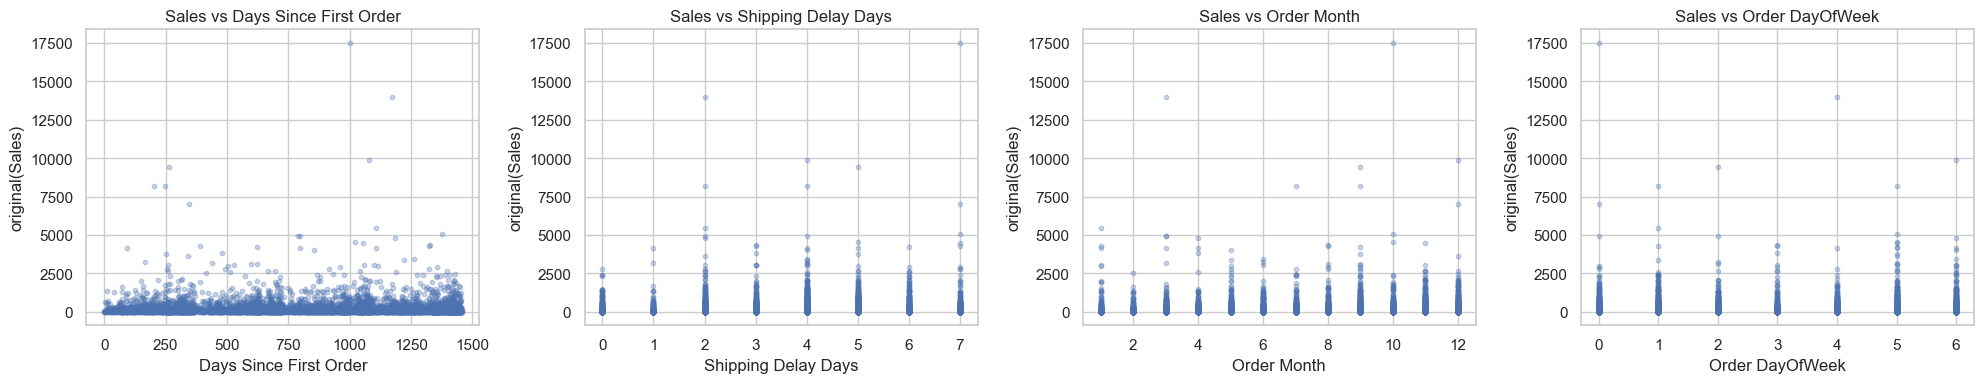

In [611]:
numeric_features = [c for c in ['Days Since First Order', 'Shipping Delay Days', 'Order Month', 'Order DayOfWeek'] if c in X_train.columns]

fig, axes = plt.subplots(1, len(numeric_features), figsize=(5 * len(numeric_features), 4))
if len(numeric_features) == 1:
    axes = [axes]
for ax, feat in zip(axes, numeric_features):
    ax.scatter(X_train[feat], y_train_orig, alpha=0.3, s=10)
    ax.set_xlabel(feat)
    ax.set_ylabel('original(Sales)')
    ax.set_title(f'Sales vs {feat}')
plt.tight_layout()
plt.show()

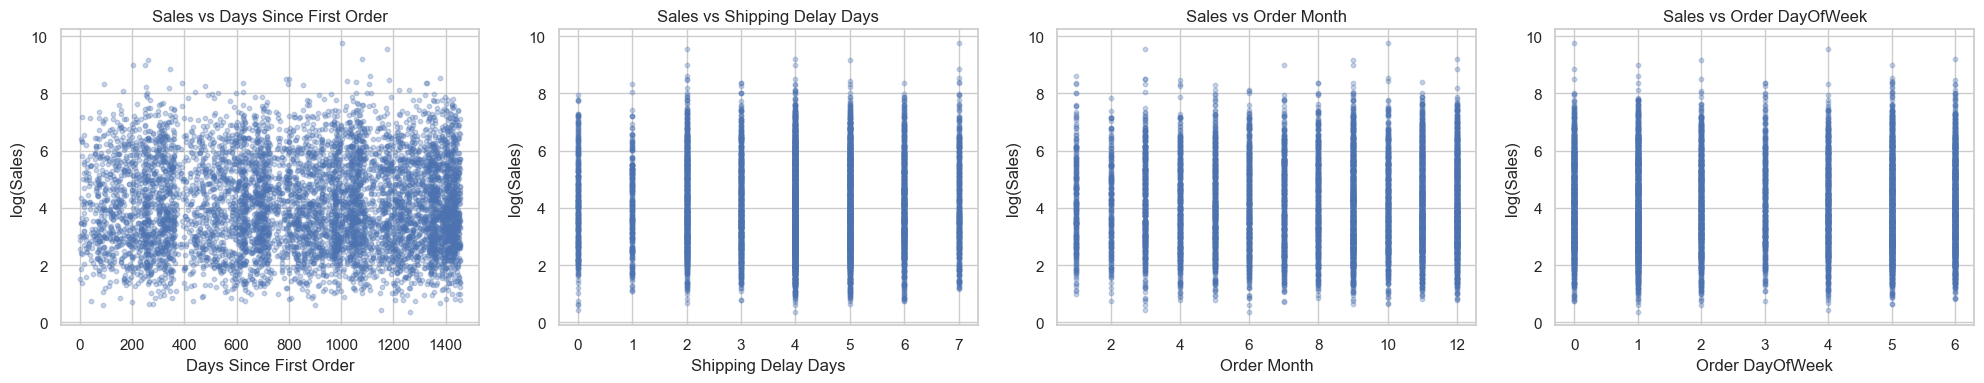

In [612]:
numeric_features = [c for c in ['Days Since First Order', 'Shipping Delay Days', 'Order Month', 'Order DayOfWeek'] if c in X_train.columns]

fig, axes = plt.subplots(1, len(numeric_features), figsize=(5 * len(numeric_features), 4))
if len(numeric_features) == 1:
    axes = [axes]
for ax, feat in zip(axes, numeric_features):
    ax.scatter(X_train[feat], y_train_log, alpha=0.3, s=10)
    ax.set_xlabel(feat)
    ax.set_ylabel('log(Sales)')
    ax.set_title(f'Sales vs {feat}')
plt.tight_layout()
plt.show()


### Task 2 — Check the linearity assumption using scatter plots

In [613]:
for feat in numeric_features:
    corr = X_train[feat].corr(y_train_orig)
    print(f"Correlation(Sales, {feat}): {corr:.3f}")

Correlation(Sales, Days Since First Order): -0.009
Correlation(Sales, Shipping Delay Days): 0.007
Correlation(Sales, Order Month): 0.006
Correlation(Sales, Order DayOfWeek): 0.006


In [614]:
# Reusing the plots above: inspect for curvature.
# We can also look at correlation coefficients as a quick linearity sanity check.
for feat in numeric_features:
    corr = X_train[feat].corr(y_train_log)
    print(f"Correlation(log Sales, {feat}): {corr:.3f}")


Correlation(log Sales, Days Since First Order): -0.005
Correlation(log Sales, Shipping Delay Days): -0.008
Correlation(log Sales, Order Month): 0.013
Correlation(log Sales, Order DayOfWeek): -0.001


### Task 3 & 4 — Fit the baseline model, then check residual normality (Q-Q plot) and homoscedasticity

In [615]:
lr = LinearRegression()
lr.fit(X_train, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](32,)","[0. ,0. ,0. ,...,0.97,0.11,0.44]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](32,)","['Order Month','Order DayOfWeek','Days Since First Order',..., 'Product Name_target_enc','City_target_enc','State_target_enc']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.636
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,32
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,32


In [616]:
train_pred_log = lr.predict(X_train)
residuals = y_train_log - train_pred_log

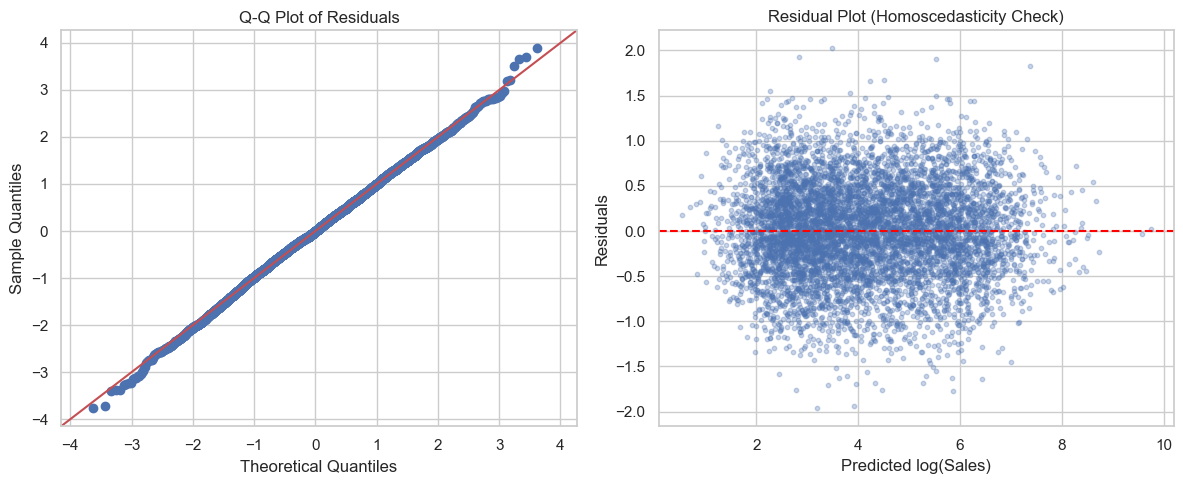

In [617]:
import statsmodels.api as sm

# Q-Q plot for normality of residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sm.qqplot(residuals, line='45', fit=True, ax=axes[0])
axes[0].set_title("Q-Q Plot of Residuals")

# Residual plot for homoscedasticity
axes[1].scatter(train_pred_log, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel("Predicted log(Sales)")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot (Homoscedasticity Check)")
plt.tight_layout()
plt.show()


### Task 5 — Build the simple Linear Regression model
(Fitted above as `lr`; repeated here for clarity as its own step.)

In [618]:
lr = LinearRegression()
lr.fit(X_train, y_train_log)
print("Model fit complete.")
print("Number of features:", X_train.shape[1])


Model fit complete.
Number of features: 32


### Task 6 — Evaluate with R² and RMSE (log scale and back-transformed original scale)

In [619]:
#Function that evaluate model over original and log Scale sale
def evaluate(model, X_tr, y_tr_log, X_te, y_te_log, y_tr_orig, y_te_orig, name="Model"):
    pred_tr_log = model.predict(X_tr)
    pred_te_log = model.predict(X_te)

    # Log-scale metrics
    r2_tr_log = r2_score(y_tr_log, pred_tr_log)
    r2_te_log = r2_score(y_te_log, pred_te_log)
    rmse_tr_log = root_mean_squared_error(y_tr_log, pred_tr_log)
    rmse_te_log = root_mean_squared_error(y_te_log, pred_te_log)

    # Back-transform to original Sales scale
    pred_tr_orig = np.expm1(pred_tr_log)
    pred_te_orig = np.expm1(pred_te_log)
    r2_tr_orig = r2_score(y_tr_orig, pred_tr_orig)
    r2_te_orig = r2_score(y_te_orig, pred_te_orig)
    rmse_tr_orig = root_mean_squared_error(y_tr_orig, pred_tr_orig)
    rmse_te_orig = root_mean_squared_error(y_te_orig, pred_te_orig)

    print(f"--- {name} ---")
    print(f"Log scale   -> Train R²: {r2_tr_log:.3f} | Test R²: {r2_te_log:.3f} | Train RMSE: {rmse_tr_log:.3f} | Test RMSE: {rmse_te_log:.3f}")
    print(f"Original    -> Train R²: {r2_tr_orig:.3f} | Test R²: {r2_te_orig:.3f} | Train RMSE: {rmse_tr_orig:.2f} | Test RMSE: {rmse_te_orig:.2f}")
    print(f"Train/Test R² gap (log scale): {r2_tr_log - r2_te_log:.3f}\n")
    return {
        "r2_train_log": r2_tr_log, "r2_test_log": r2_te_log,
        "rmse_train_log": rmse_tr_log, "rmse_test_log": rmse_te_log,
        "r2_train_orig": r2_tr_orig, "r2_test_orig": r2_te_orig,
        "rmse_train_orig": rmse_tr_orig, "rmse_test_orig": rmse_te_orig,
    }


In [620]:
lr_results = evaluate(lr, X_train, y_train_log, X_test, y_test_log, y_train_orig, y_test_orig, "Linear Regression")

--- Linear Regression ---
Log scale   -> Train R²: 0.891 | Test R²: 0.760 | Train RMSE: 0.521 | Test RMSE: 0.798
Original    -> Train R²: 0.809 | Test R²: 0.380 | Train RMSE: 238.98 | Test RMSE: 614.66
Train/Test R² gap (log scale): 0.131



### Task 7 — Plot actual vs predicted Sales

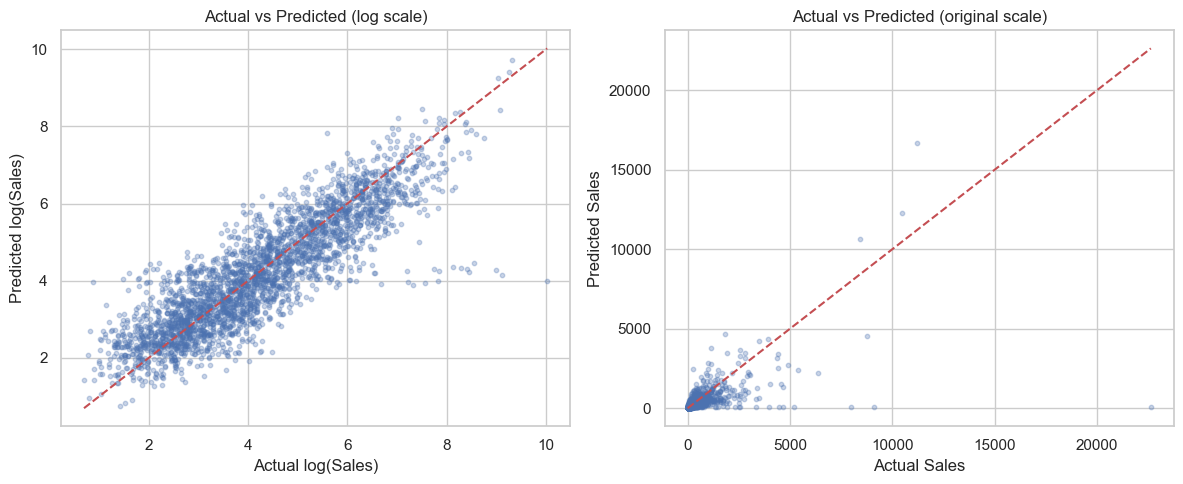

In [621]:
test_pred_log = lr.predict(X_test)
test_pred_orig = np.expm1(test_pred_log)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test_log, test_pred_log, alpha=0.3, s=10)
axes[0].plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 'r--')
axes[0].set_xlabel("Actual log(Sales)")
axes[0].set_ylabel("Predicted log(Sales)")
axes[0].set_title("Actual vs Predicted (log scale)")

axes[1].scatter(y_test_orig, test_pred_orig, alpha=0.3, s=10)
axes[1].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--')
axes[1].set_xlabel("Actual Sales")
axes[1].set_ylabel("Predicted Sales")
axes[1].set_title("Actual vs Predicted (original scale)")
plt.tight_layout()
plt.show()


### Task 8 — Interpret the model coefficients

In [622]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr.coef_
}).sort_values('coefficient', key=abs, ascending=False)

coef_df['approx_pct_effect_on_sales'] = (np.exp(coef_df['coefficient']) - 1) * 100
print(coef_df.to_string(index=False))


                 feature  coefficient  approx_pct_effect_on_sales
 Product Name_target_enc     0.967833                  163.223492
        State_target_enc     0.441106                   55.442546
Customer Name_target_enc     0.113850                   12.058356
         City_target_enc     0.108031                   11.408191
      Ship Mode_Same Day    -0.064174                   -6.215813
   Sub-Category_Machines     0.056264                    5.787655
            Region_South     0.052623                    5.403262
             Region_West     0.038740                    3.950056
  Sub-Category_Bookcases     0.038665                    3.942198
     Sub-Category_Labels    -0.026905                   -2.654632
Ship Mode_Standard Class     0.025247                    2.556811
     Sub-Category_Chairs     0.021792                    2.203158
       Segment_Corporate     0.019333                    1.952059
     Segment_Home Office     0.018797                    1.897468
          

### Task 9 — Add interaction terms and polynomial features (numeric features only)

In [623]:
from sklearn.preprocessing import PolynomialFeatures

poly_input_cols = numeric_features  # only the genuinely numeric/engineered columns
poly2 = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly2 = poly2.fit_transform(X_train[poly_input_cols])
X_test_poly2 = poly2.transform(X_test[poly_input_cols])

poly2_feature_names = poly2.get_feature_names_out(poly_input_cols)
X_train_poly2_df = pd.DataFrame(X_train_poly2, columns=poly2_feature_names, index=X_train.index)
X_test_poly2_df = pd.DataFrame(X_test_poly2, columns=poly2_feature_names, index=X_test.index)

# Combine polynomial numeric features with the remaining (already encoded) categorical features
other_cols = [c for c in X_train.columns if c not in poly_input_cols]
X_train_poly2_full = pd.concat([X_train_poly2_df, X_train[other_cols]], axis=1)
X_test_poly2_full = pd.concat([X_test_poly2_df, X_test[other_cols]], axis=1)

print(f"Train shape(poly-2): {X_train_poly2_full.shape}")


Train shape(poly-2): (6860, 42)


### Task 10 — Build Polynomial Regression models (degree 2 and 3)

In [624]:
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train[poly_input_cols])
X_test_poly3 = poly3.transform(X_test[poly_input_cols])
poly3_feature_names = poly3.get_feature_names_out(poly_input_cols)
X_train_poly3_df = pd.DataFrame(X_train_poly3, columns=poly3_feature_names, index=X_train.index)
X_test_poly3_df = pd.DataFrame(X_test_poly3, columns=poly3_feature_names, index=X_test.index)

X_train_poly3_full = pd.concat([X_train_poly3_df, X_train[other_cols]], axis=1)
X_test_poly3_full = pd.concat([X_test_poly3_df, X_test[other_cols]], axis=1)

poly2_model = LinearRegression().fit(X_train_poly2_full, y_train_log)
poly3_model = LinearRegression().fit(X_train_poly3_full, y_train_log)

#evaluate Polynomial Regression (degree=2, 3)
poly2_results = evaluate(poly2_model, X_train_poly2_full, y_train_log, X_test_poly2_full, y_test_log,
                          y_train_orig, y_test_orig, "Polynomial Regression (degree=2)")
poly3_results = evaluate(poly3_model, X_train_poly3_full, y_train_log, X_test_poly3_full, y_test_log,
                          y_train_orig, y_test_orig, "Polynomial Regression (degree=3)")


--- Polynomial Regression (degree=2) ---
Log scale   -> Train R²: 0.885 | Test R²: 0.751 | Train RMSE: 0.535 | Test RMSE: 0.811
Original    -> Train R²: 0.794 | Test R²: 0.363 | Train RMSE: 248.33 | Test RMSE: 622.86
Train/Test R² gap (log scale): 0.133

--- Polynomial Regression (degree=3) ---
Log scale   -> Train R²: 0.001 | Test R²: -0.003 | Train RMSE: 1.575 | Test RMSE: 1.629
Original    -> Train R²: -0.079 | Test R²: -0.069 | Train RMSE: 568.04 | Test RMSE: 807.21
Train/Test R² gap (log scale): 0.003



### Task 11 — Compare Polynomial vs Linear Regression

In [625]:
comparison = pd.DataFrame({
    'Linear': lr_results,
    'Polynomial (deg=2)': poly2_results,
    'Polynomial (deg=3)': poly3_results,
}).T
print(comparison[['r2_train_log', 'r2_test_log', 'rmse_train_log', 'rmse_test_log']])


                    r2_train_log  r2_test_log  rmse_train_log  rmse_test_log
Linear                  0.890681     0.759558        0.521112       0.797689
Polynomial (deg=2)      0.884779     0.751470        0.534993       0.810994
Polynomial (deg=3)      0.000817    -0.002605        1.575451       1.628895


### Task 12 — Ridge regression with alpha tuning

In [626]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_params = {'alpha': [0.01, 0.1, 1, 5, 10, 50, 100]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, scoring='r2', cv=5)
ridge_grid.fit(X_train, y_train_log)

print("Best Ridge alpha:", ridge_grid.best_params_)
ridge_best = ridge_grid.best_estimator_
ridge_results = evaluate(ridge_best, X_train, y_train_log, X_test, y_test_log, y_train_orig, y_test_orig, "Ridge Regression")


Best Ridge alpha: {'alpha': 50}
--- Ridge Regression ---
Log scale   -> Train R²: 0.891 | Test R²: 0.759 | Train RMSE: 0.521 | Test RMSE: 0.799
Original    -> Train R²: 0.806 | Test R²: 0.381 | Train RMSE: 240.54 | Test RMSE: 614.00
Train/Test R² gap (log scale): 0.132



### Task 13 — Lasso regression with alpha tuning

In [630]:
from sklearn.linear_model import Lasso

lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_params, scoring='r2', cv=5)
lasso_grid.fit(X_train, y_train_log)

print("Best Lasso alpha:", lasso_grid.best_params_)
lasso_best = lasso_grid.best_estimator_
lasso_results = evaluate(lasso_best, X_train, y_train_log, X_test, y_test_log, y_train_orig, y_test_orig, "Lasso Regression")

n_zero = np.sum(lasso_best.coef_ == 0)
print(f"Lasso zeroed out {n_zero} of {len(lasso_best.coef_)} coefficients (feature selection effect).")


Best Lasso alpha: {'alpha': 0.001}
--- Lasso Regression ---
Log scale   -> Train R²: 0.891 | Test R²: 0.758 | Train RMSE: 0.521 | Test RMSE: 0.800
Original    -> Train R²: 0.810 | Test R²: 0.377 | Train RMSE: 238.38 | Test RMSE: 616.18
Train/Test R² gap (log scale): 0.133

Lasso zeroed out 17 of 32 coefficients (feature selection effect).


### Task 14 — Compare Linear, Ridge, and Lasso

In [628]:
final_comparison = pd.DataFrame({
    'Linear': lr_results,
    'Ridge': ridge_results,
    'Lasso': lasso_results,
}).T
print(final_comparison[['r2_train_log', 'r2_test_log', 'rmse_train_log', 'rmse_test_log']])


        r2_train_log  r2_test_log  rmse_train_log  rmse_test_log
Linear      0.890681     0.759558        0.521112       0.797689
Ridge       0.890607     0.759034        0.521287       0.798557
Lasso       0.890577     0.757903        0.521360       0.800429


### Task 15 — 5-fold cross-validation for all models

In [629]:
from sklearn.model_selection import cross_val_score

models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=ridge_grid.best_params_['alpha']),
    'Lasso': Lasso(alpha=lasso_grid.best_params_['alpha'], max_iter=10000),
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train_log, cv=5, scoring='r2')
    cv_results[name] = scores
    print(f"{name}: CV R² scores = {np.round(scores, 3)} | Mean = {scores.mean():.3f} | Std = {scores.std():.3f}")


Linear: CV R² scores = [0.898 0.887 0.891 0.889 0.881] | Mean = 0.889 | Std = 0.005
Ridge: CV R² scores = [0.897 0.887 0.891 0.89  0.881] | Mean = 0.889 | Std = 0.005
Lasso: CV R² scores = [0.898 0.887 0.891 0.89  0.882] | Mean = 0.890 | Std = 0.005
